# 01 · Data Exploration — MIT-BIH Arrhythmia Database

Initial exploration of the MIT-BIH dataset downloaded directly from PhysioNet via `wfdb`.

* Loads record 100 and inspects sampling frequency, duration and beat annotations
* Visualizes a 10-second ECG segment with beat labels overlaid

No local files required — data streams directly from PhysioNet.

In [ ]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt

# Download record 100 from MIT-BIH directly from PhysioNet
record = wfdb.rdrecord('100', pn_dir='mitdb')
annotations = wfdb.rdann('100', 'atr', pn_dir='mitdb')

print("Sampling frequency:", record.fs, "Hz")
print("Duration:", record.sig_len / record.fs / 60, "minutes")
print("Total annotated beats:", len(annotations.sample))
print("Unique beat types:", set(annotations.symbol))

Sampling frequency: 360 Hz
Duration: 30.092592592592595 minutes
Total annotated beats: 2274
Unique beat types: {'N', 'A', '+', 'V'}


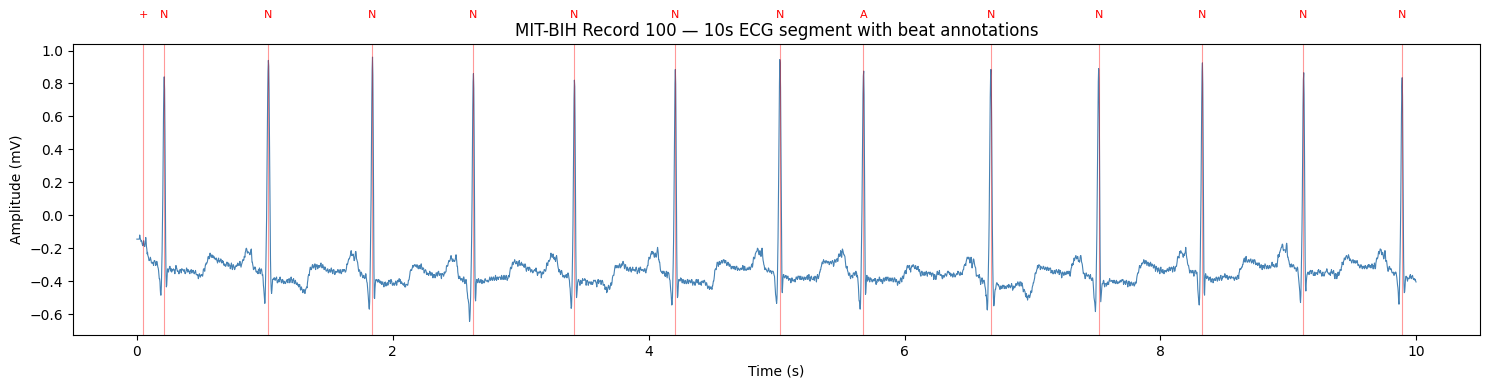

In [ ]:
# Visualize a 10-second ECG segment with beat annotations
fs = record.fs
start, end = 0, 10 * fs  # 10 seconds

signal = record.p_signal[:, 0]  # Lead I

# Get annotations within this window
mask = (annotations.sample >= start) & (annotations.sample < end)
ann_samples = annotations.sample[mask]
ann_labels = np.array(annotations.symbol)[mask]

plt.figure(figsize=(15, 4))
plt.plot(np.arange(start, end) / fs, signal[start:end], color='steelblue', linewidth=0.8)

for sample, label in zip(ann_samples, ann_labels):
    plt.axvline(x=sample / fs, color='red', alpha=0.4, linewidth=0.8)
    plt.text(sample / fs, 1.2, label, fontsize=8, color='red', ha='center')

plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title("MIT-BIH Record 100 — 10s ECG segment with beat annotations")
plt.tight_layout()
plt.show()